In [27]:
import xarray as xr 
import numpy as np 
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import proj3d
from sklearn.neighbors import KDTree
from collections import defaultdict

In [28]:
DIR = "/Users/knv2/Documents/codebase/AFL-tutorial/3DPhaseDiagram"
boundary_dataset = xr.load_dataset(DIR+'/dataset/250610-extrap_expand_dataset.nc')

In [29]:
xyz = boundary_dataset.composition.values.T[:,[0,2,1]]
ell = boundary_dataset.labels.values

In [30]:
def find_boundary_points(points, labels, k=10):
    """
    Identify boundary points in a point cloud with labels using KDTree.
    
    Parameters
    ----------
    points : ndarray of shape (N, 3)
        3D coordinates of points
    labels : ndarray of shape (N,)
        Class labels (e.g. +1/-1 or multiclass)
    k : int
        Number of neighbors to check for label differences
    
    Returns
    -------
    boundaries : dict
        Dictionary where keys are (label_a, label_b) tuples and values 
        are arrays of boundary points lying between those classes.
    """
    tree = KDTree(points)
    boundaries = defaultdict(list)

    for i, p in enumerate(points):
        _, idx = tree.query([p], k=k)
        neighbor_labels = labels[idx[0]]
        
        # Compare with current point’s label
        current_label = labels[i]
        diff_labels = set(neighbor_labels) - {current_label}
        
        for other_label in diff_labels:
            key = tuple(sorted((current_label.item(), other_label.item())))
            boundaries[key].append(p)

    # Convert lists to numpy arrays
    return {k: np.array(v) for k, v in boundaries.items()}

boundaries = find_boundary_points(xyz, ell, k=16)

for key, val in boundaries.items():
    print(f"Boundary {key}: {len(val)} points")

Boundary (0, 1): 2722 points
Boundary (1, 2): 1809 points


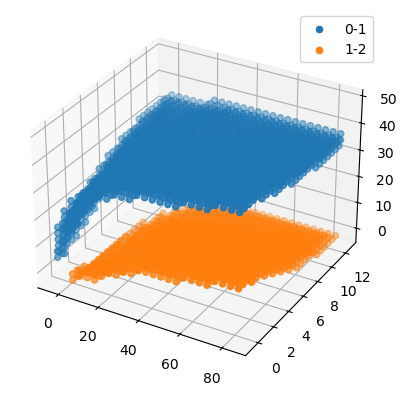

In [31]:
fig, ax = plt.subplots(subplot_kw={"projection":"3d"})
for key, points in boundaries.items():
    ax.scatter(
        points[:,0],
        points[:,1],
        points[:,2],
        label = "-".join(f"{k}" for k in key)
    )
ax.legend()
plt.show()

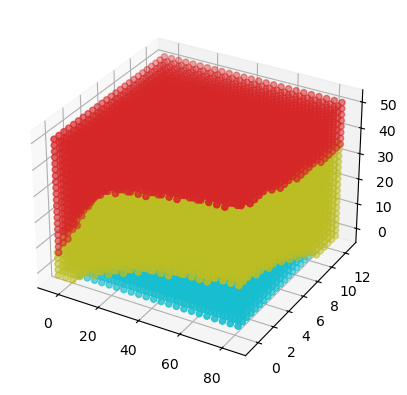

In [32]:
fig, ax = plt.subplots(subplot_kw={"projection":"3d"})
phase_colors =['tab:red','tab:olive','tab:cyan']
for label in np.unique(ell):
    mask = ell==label
    ax.scatter(
        xyz[mask,0],
        xyz[mask,1],
        xyz[mask,2],
        color = phase_colors[label]
    )

In [33]:
import torch
import torch.optim as optim
import numpy as np

import matplotlib.pyplot as plt

from funcshape.surface import PointCloudSurface
from funcshape.transforms import SRNF
from funcshape.visual import (
    get_common_colornorm,
    plot_surface,
    plot_diffeomorphism_2d,
)
    
from funcshape.networks import SurfaceReparametrizer
from funcshape.layers.sinefourier import SineFourierLayer
from funcshape.loss import SurfaceDistance
from funcshape.reparametrize import reparametrize
from funcshape.logging import Logger

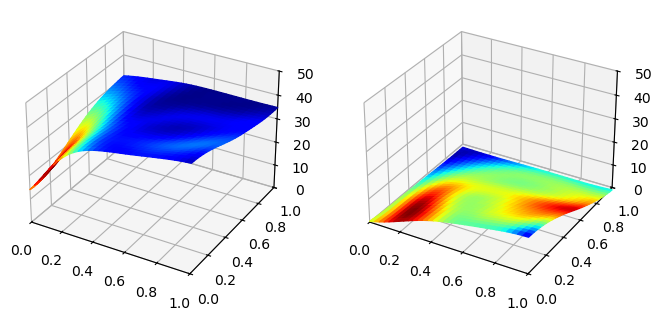

In [34]:
f = PointCloudSurface(boundaries[(0,1)])
g = PointCloudSurface(boundaries[(1,2)])
fig, axs = plt.subplots(
    1,2,
    figsize=(4*2, 4), 
    subplot_kw = {"projection":"3d"}
)
plot_surface(f, ax = axs[0])
plot_surface(g, ax = axs[1])
for ax in axs:
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.0])
    ax.set_zlim([0.0, 50.0])
plt.show()

[Iter     1] loss: 7.322618
[Iter     2] loss: 6.978628
[Iter     3] loss: 6.978629
Finished training in 5.09218s


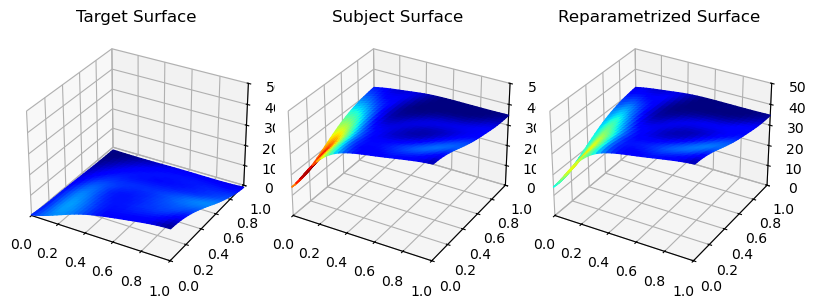

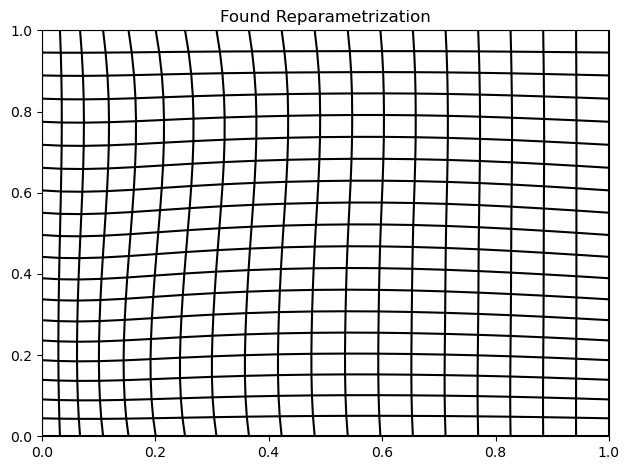

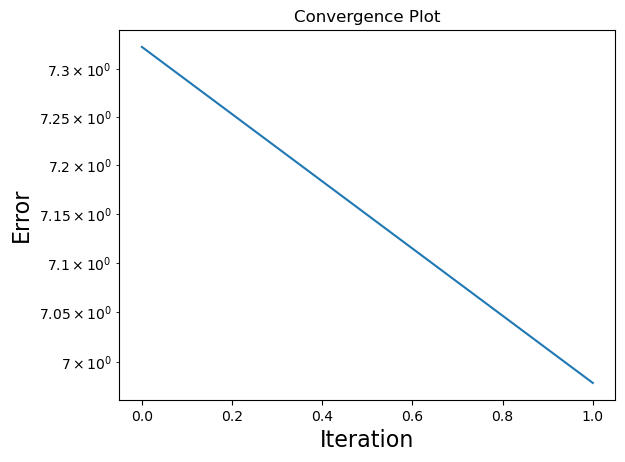

In [35]:
q = SRNF(g)
r = SRNF(f)

# Use GPU capabilities? Makes small differences for small networks,
# but is significantly more scalable.
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# device = "cpu"

# Define reparametrization-network
RN = SurfaceReparametrizer(
    [SineFourierLayer(10) for _ in range(10)]
).to(device)
loss_func = SurfaceDistance(q, r, k=32, h=1e-4).to(device)

optimizer = optim.LBFGS(RN.parameters(), max_iter=30, line_search_fn="strong_wolfe")
errors = reparametrize(RN, loss_func, optimizer, 30, Logger(1))
RN.to("cpu"), loss_func.to("cpu"); # Need on CPU for plotting.
RN.detach()

# Reparametrize f
fafter = f.compose(RN)

# Create Coloring Functions for plotting
k = 32 # Points per dimension (k^2 points total)
camera = (35, 225)
norm = get_common_colornorm((f, g, fafter), k=k)

fig = plt.figure(figsize=(8, 4))
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
ax2 = fig.add_subplot(1, 3, 2, projection="3d")
ax3 = fig.add_subplot(1, 3, 3, projection='3d')

plot_surface(g, ax=ax1, k=k, colornorm=norm)
ax1.set_title("Target Surface")
plot_surface(f, ax=ax2, k=k, colornorm=norm)
ax2.set_title("Subject Surface")
plot_surface(fafter, ax=ax3, k=k, colornorm=norm)
ax3.set_title("Reparametrized Surface")
for ax in [ax1, ax2, ax3]:
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.0])
    ax.set_zlim([0.0, 50.0])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
plot_diffeomorphism_2d(RN, k=20, color="k", ax=ax)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title("Found Reparametrization")
plt.tight_layout()
plt.show()

plt.figure()
plt.semilogy(errors)
plt.axhline(0., ls="--", c="black")
plt.ylabel("Error", fontsize=16)
plt.xlabel("Iteration", fontsize=16)
plt.title("Convergence Plot")
plt.show()

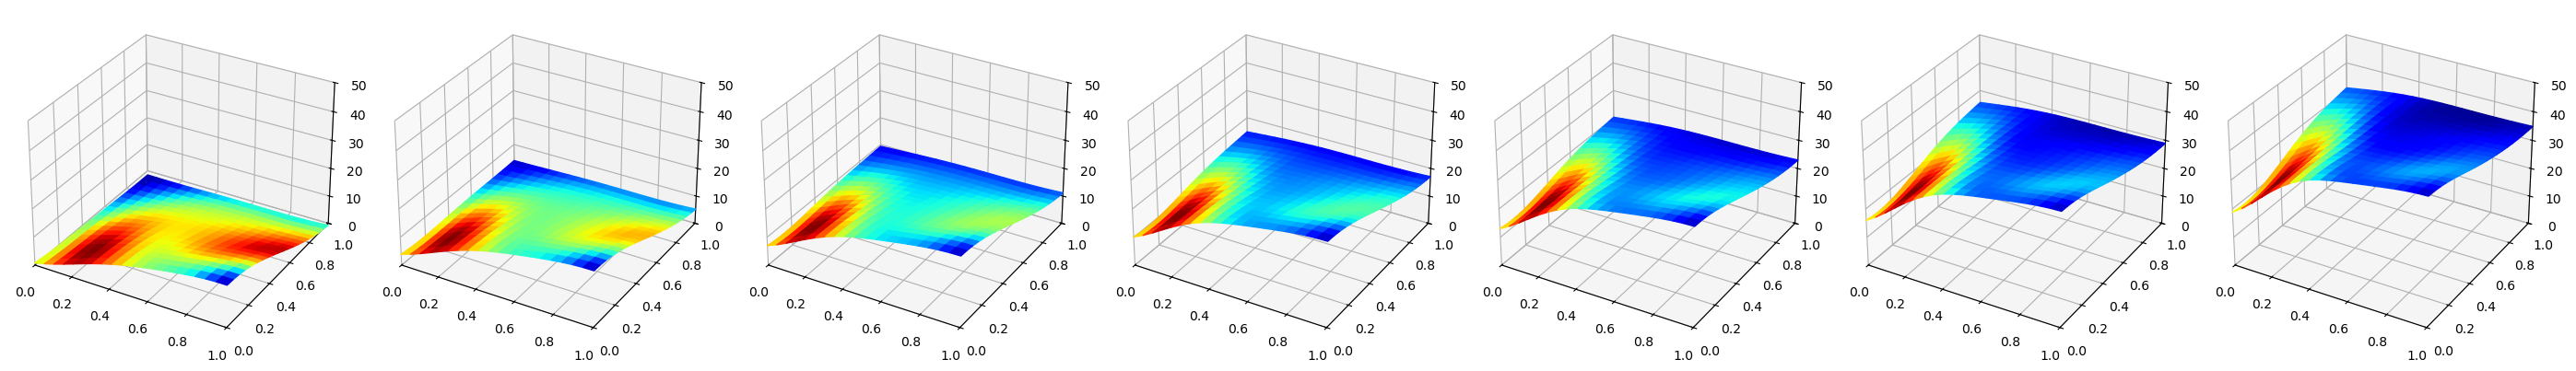

In [36]:
from funcshape.interpolation import linear_interpolate

k = 30
X, Y = torch.meshgrid((torch.linspace(0, 1, k), torch.linspace(0, 1, k)))
X, Y = X.reshape(-1, 1), Y.reshape(-1, 1)
X = torch.cat((X, Y), dim=1)
numsteps = 7
fig = plt.figure(figsize=(7*4, 4))
for i, h in enumerate(linear_interpolate(lambda x: g(RN(x)), f, numsteps)):
    ax = fig.add_subplot(1, numsteps, i+1, projection="3d")
    pts = h(X).detach().cpu().numpy()
    si = PointCloudSurface(pts)
    plot_surface(si, k=20, ax = ax)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.0])
    ax.set_zlim([0.0, 50.0])
plt.tight_layout()
plt.show()

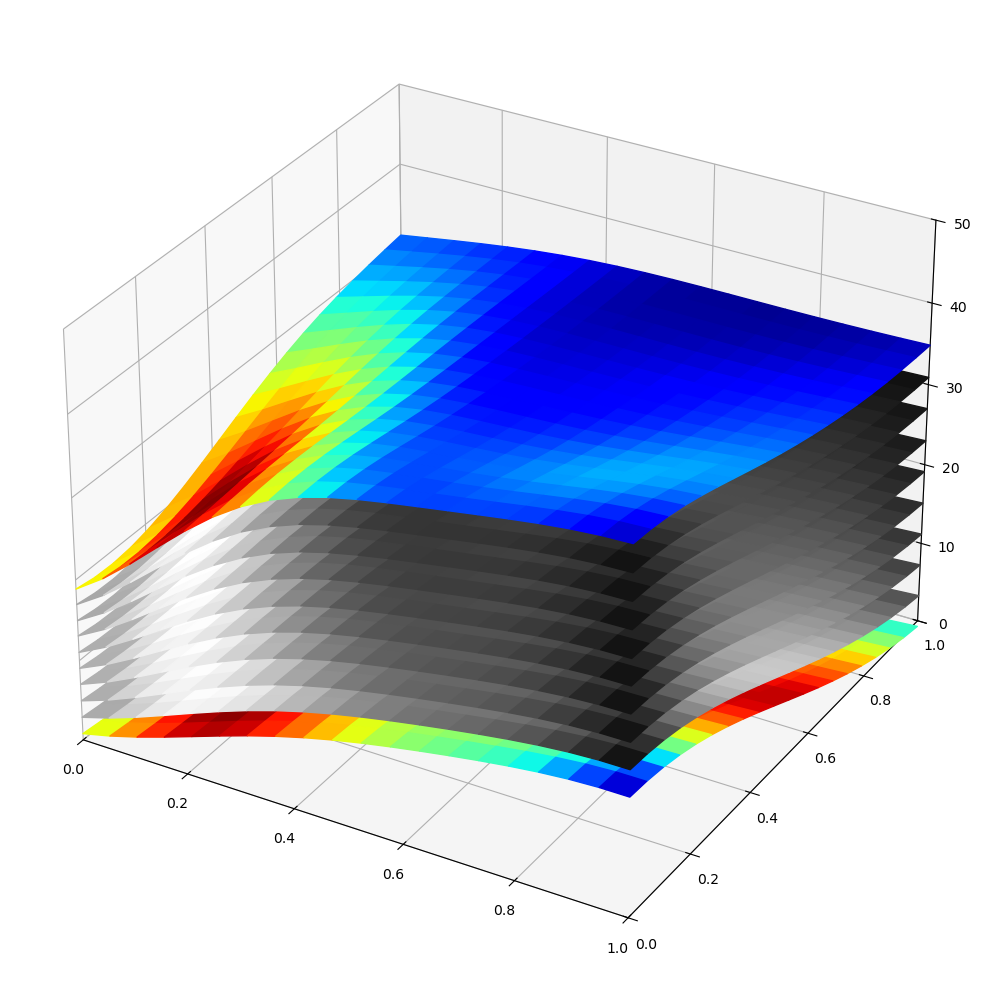

In [37]:
k = 30
X, Y = torch.meshgrid((torch.linspace(0, 1, k), torch.linspace(0, 1, k)))
X, Y = X.reshape(-1, 1), Y.reshape(-1, 1)
X = torch.cat((X, Y), dim=1)
numsteps = 10
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1, 1, 1, projection="3d")
for i, h in enumerate(linear_interpolate(lambda x: g(RN(x)), f, numsteps)):
    if i in [0,9]:
        cmap = plt.get_cmap("jet")
    else:
        cmap = plt.get_cmap("grey")
    pts = h(X).detach().cpu().numpy()
    si = PointCloudSurface(pts)
    plot_surface(si, k=20, ax = ax, colormap=cmap)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.0])
ax.set_zlim([0.0, 50.0])
plt.tight_layout()
plt.show()

In [38]:
from matplotlib.animation import FuncAnimation, PillowWriter

# --- Your existing setup ---
k = 30
X, Y = torch.meshgrid(torch.linspace(0, 1, k), torch.linspace(0, 1, k))
X, Y = X.reshape(-1, 1), Y.reshape(-1, 1)
X = torch.cat((X, Y), dim=1)
numsteps = 10

# Precompute all surfaces
surfaces = []
for h in linear_interpolate(lambda x: g(RN(x)), f, numsteps):
    pts = h(X).detach().cpu().numpy()
    surfaces.append(PointCloudSurface(pts))

# --- Animation setup ---
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 1, 1, projection="3d")

def init():
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.0])
    ax.set_zlim([0.0, 50.0])
    ax.set_title("Surface Evolution from t=0 to t=10")
    return []

def update(frame):
    ax.cla()  # Clear axis for new frame
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.0])
    ax.set_zlim([0.0, 50.0])
    ax.set_title(f"Surface Evolution (t={frame})")

    # Plot initial surface (t=0) in grey
    plot_surface(surfaces[0], k=20, ax=ax, colormap=plt.get_cmap("gray"))

    # Plot current surface (t=frame) in color
    cmap = plt.get_cmap("jet")
    plot_surface(surfaces[frame], k=20, ax=ax, colormap=cmap)

    return []

# --- Create animation ---
anim = FuncAnimation(
    fig, update, frames=range(numsteps), init_func=init, blit=False
)

# --- Save as GIF ---
anim.save("surface_evolution.gif", writer=PillowWriter(fps=2))
plt.close(fig)